# **Workshop Machine Learning**
## Algoritma Klasifikasi:
## Decision Tree · Random Forest · SVM
### Studi kasus:
### Klasifikasi Status Diabetes Pasien

### Tujuan Proyek Klasifikasi
Tujuan dari notebook ini adalah membangun model machine learning yang dapat mengklasifikasikan pasien ke dalam 3 kategori: **Diabetes**, **Prediabetes**, atau **Non-Diabetes** menggunakan indikator medis yang paling signifikan.


# Import Library

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

print("Library siap ✅")

Library siap ✅


Kode tersebut digunakan untuk **menyiapkan library yang diperlukan untuk proses machine learning klasifikasi**.

* `pandas` → mengolah dan membaca dataset.
* `matplotlib` & `seaborn` → membuat visualisasi/grafik.
* `train_test_split` → membagi data menjadi data training dan testing.
* `LabelEncoder` → mengubah data kategori menjadi angka.
* `StandardScaler` → melakukan standarisasi data.
* `DecisionTreeClassifier` → algoritma klasifikasi Decision Tree.
* `RandomForestClassifier` → algoritma klasifikasi Random Forest.
* `SVC` → algoritma klasifikasi Support Vector Machine (SVM).
* `accuracy_score`, `classification_report`, `ConfusionMatrixDisplay` → mengevaluasi hasil model.
* `sns.set_style()` dan `plt.rcParams` → mengatur tampilan grafik.

**Intinya:** kode ini merupakan tahap **persiapan tools/library sebelum melakukan preprocessing, training, dan evaluasi model machine learning**.


In [68]:
df = pd.read_csv("/content/Dataset of Diabetes .csv")
df.columns = [c.strip() for c in df.columns]

df["CLASS"] = df["CLASS"].str.strip().str.upper().map(
    {"N": "Non-Diabetes", "P": "Prediabetes", "Y": "Diabetes"}
    )
df["Gender"] = df["Gender"].str.strip().str.upper()
df = df.drop(columns=["ID", "No_Pation"])

print("Jumlah baris:", df.shape[0])
df["CLASS"].value_counts()

Jumlah baris: 1000


,count
CLASS,
Diabetes,844
Non-Diabetes,103
Prediabetes,53


Output tersebut menunjukkan **jumlah data dan distribusi setiap kelas**. Jika jumlah data pada **Non-Diabetes, Prediabetes, dan Diabetes berbeda jauh**, berarti dataset **tidak seimbang (imbalanced)**, sehingga model bisa lebih cenderung memprediksi kelas yang jumlah datanya lebih banyak.

Karena dataset memiliki **jumlah data antar kelas yang tidak seimbang**, digunakan **`class_weight="balanced"`** pada model **SVM, Decision Tree, dan Random Forest** saat proses klasifikasi. Parameter ini secara otomatis memberikan bobot lebih besar pada kelas yang jumlah datanya lebih sedikit dan bobot lebih kecil pada kelas yang jumlah datanya lebih banyak, sehingga model dapat melakukan klasifikasi secara lebih seimbang.


# Mencari Missing Value

In [69]:
missing_data = df.isnull().sum()
print("Jumlah data hilang per kolom:")
print(missing_data[missing_data > 0] if missing_data.any() else "Tidak ada data hilang (0% missing).")

Jumlah data hilang per kolom:
Tidak ada data hilang (0% missing).


Output tersebut menunjukkan bahwa **tidak terdapat data yang hilang pada seluruh kolom dataset**, sehingga **tidak diperlukan proses penanganan missing value**.


# Menunjukan 5 Baris Data Teratas

In [70]:
df.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,Non-Diabetes
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,Non-Diabetes
2,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,Non-Diabetes
3,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,Non-Diabetes
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,Non-Diabetes


Kolom-kolom tersebut merupakan **parameter kesehatan yang digunakan sebagai fitur dalam dataset**:

* **Gender** → jenis kelamin.
* **AGE** → usia pasien (tahun).
* **Urea** → kadar urea dalam darah, berkaitan dengan fungsi ginjal.
* **Cr (Creatinine)** → kadar kreatinin dalam darah, juga digunakan untuk melihat fungsi ginjal.
* **HbA1c** → rata-rata kadar gula darah dalam 2–3 bulan terakhir.
* **Chol (Cholesterol)** → kadar kolesterol dalam darah.
* **TG (Triglycerides)** → kadar trigliserida dalam darah.
* **HDL** → jenis kolesterol yang sering disebut *kolesterol baik*.
* **LDL** → jenis kolesterol yang sering disebut *kolesterol jahat*.
* **VLDL** → jenis lipoprotein yang membawa terutama trigliserida dalam darah.
* **BMI** → indeks massa tubuh, menunjukkan perbandingan berat badan dengan tinggi badan.
* **CLASS** → label/kelas yang ingin diprediksi: **Diabetes, Prediabetes, atau Non-Diabetes**.

Jadi, **Urea, Cr, HbA1c, Chol, TG, HDL, LDL, VLDL, dan BMI** merupakan data kondisi tubuh pasien yang digunakan model untuk membantu menentukan **kelas diabetes**.


# Statistik Deskriptif & Cek Kualitas Data

In [71]:
df.describe()

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.528000,5.124743,68.943000,8.281160,4.862820,2.349610,1.204750,2.609790,1.854700,29.578020
std,8.799241,2.935165,59.984747,2.534003,1.301738,1.401176,0.660414,1.115102,3.663599,4.962388
min,20.000000,0.500000,6.000000,0.900000,0.000000,0.300000,0.200000,0.300000,0.100000,19.000000
25%,51.000000,3.700000,48.000000,6.500000,4.000000,1.500000,0.900000,1.800000,0.700000,26.000000
50%,55.000000,4.600000,60.000000,8.000000,4.800000,2.000000,1.100000,2.500000,0.900000,30.000000
75%,59.000000,5.700000,73.000000,10.200000,5.600000,2.900000,1.300000,3.300000,1.500000,33.000000
max,79.000000,38.900000,800.000000,16.000000,10.300000,13.800000,9.900000,9.900000,35.000000,47.750000


**Kenapa langkah ini penting:** `.describe()` menunjukkan ringkasan statistik (rata-rata, minimum, maksimum, dll) tiap kolom numerik, dan **berguna untuk mendeteksi data yang mustahil secara medis** sebelum data dipakai untuk melatih model.

**Temuan penting:** kolom `Chol` (kolesterol total) punya nilai **minimum 0.0** — ini **tidak mungkin terjadi pada manusia hidup** (kolesterol 0 secara medis mustahil). Ini menandakan kemungkinan ada **kesalahan input data** atau **nilai yang hilang dicatat sebagai 0** alih-alih `NaN`.



# Perbaiki Nilai Cacat

In [72]:
# Cek dulu berapa baris yang bermasalah
print("Jumlah baris dengan Chol = 0:", (df["Chol"] == 0).sum())

# Hapus baris yang Chol-nya 0
df = df[df["Chol"] != 0].reset_index(drop=True)

print("Jumlah baris setelah dibersihkan:", df.shape[0])

Jumlah baris dengan Chol = 0: 1
Jumlah baris setelah dibersihkan: 999


Output menunjukkan bahwa terdapat **1 baris dengan nilai `Chol = 0`**. Setelah baris tersebut dihapus, jumlah data menjadi **999 baris**.


# Menentukan Feature Importance Dengan Random **Forest**

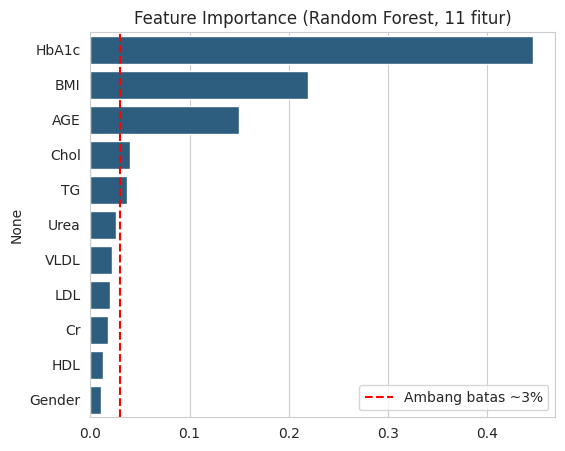

,0
HbA1c,0.446487
BMI,0.219358
AGE,0.149649
Chol,0.039770
TG,0.036948
Urea,0.025422
VLDL,0.021653
LDL,0.019947
Cr,0.017452
HDL,0.012591


In [73]:
df_full = df.copy()
df_full["Gender"] = df_full["Gender"].map({"M": 0, "F": 1})

le = LabelEncoder()
df_full["CLASS_encoded"] = le.fit_transform(df_full["CLASS"])

fitur_semua = ["Gender", "AGE", "Urea", "Cr", "HbA1c", "Chol", "TG", "HDL", "LDL", "VLDL", "BMI"]
X_full = df_full[fitur_semua]
y_full = df_full["CLASS_encoded"]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.25, random_state=42, stratify=y_full
)

# Model sementara, hanya untuk mengecek feature importance
rf_cek = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight="balanced")
rf_cek.fit(X_train_full, y_train_full)

importance = pd.Series(rf_cek.feature_importances_, index=fitur_semua).sort_values(ascending=False)

plt.figure(figsize=(6, 5))
sns.barplot(x=importance.values, y=importance.index, color="#1F618D")
plt.title("Feature Importance (Random Forest, 11 fitur)")
plt.axvline(0.03, color="red", linestyle="--", label="Ambang batas ~3%")
plt.legend()
plt.show()

importance

# Interpretasi Feature Importance
Grafik tersebut menunjukkan **feature importance dari Random Forest** terhadap 11 fitur.

* **HbA1c** → fitur paling berpengaruh dalam klasifikasi, sekitar **45%**.
* **BMI** → pengaruh kedua terbesar, sekitar **22%**.
* **AGE** → sekitar **15%**, juga cukup berpengaruh.
* **Chol, TG, Urea, VLDL, Cr, LDL, HDL, dan Gender** → pengaruhnya relatif kecil.
* Garis merah putus-putus (**~3%**) merupakan **ambang batas**. Fitur di atas garis dianggap memiliki kontribusi yang lebih signifikan dibanding fitur di bawahnya.

**Kesimpulan:** Random Forest paling banyak menggunakan informasi dari **HbA1c, BMI, dan AGE** dalam menentukan kelas **Non-Diabetes, Prediabetes, atau Diabetes**.

**Random Forest digunakan karena selain dapat melakukan klasifikasi, model ini juga dapat memberikan nilai `feature_importances_` yang menunjukkan seberapa besar kontribusi setiap fitur terhadap hasil klasifikasi.** Dengan demikian, Random Forest dipilih untuk mengetahui fitur mana yang paling berpengaruh dalam menentukan apakah data termasuk **Non-Diabetes, Prediabetes, atau Diabetes**, seperti HbA1c, BMI, dan AGE.


# Penjelasan 5 Kolom Teripilih
Lima kolom yang dipilih adalah **HbA1c, BMI, AGE, Chol, dan TG**. **HbA1c** menjadi fitur paling penting karena menunjukkan rata-rata gula darah 2–3 bulan terakhir. **BMI** berkaitan dengan kondisi berat badan dan risiko diabetes, sedangkan **AGE** menunjukkan bahwa risiko diabetes dapat meningkat seiring bertambahnya usia. **Chol** menunjukkan kadar kolesterol dan **TG** menunjukkan kadar trigliserida, yang keduanya berkaitan dengan kondisi metabolisme tubuh.


##Preprocessing dengan 5 Fitur Terpilih

In [74]:
fitur = ["HbA1c", "BMI", "AGE", "Chol", "TG"]
X = df_full[fitur]
y = df_full["CLASS_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Data latih: {len(X_train)} baris | Data uji: {len(X_test)} baris | Jumlah fitur: {len(fitur)}")

Data latih: 749 baris | Data uji: 250 baris | Jumlah fitur: 5


Output menunjukkan data sudah **dipreprocessing** dengan membagi 1000 data menjadi **750 data latih dan 250 data uji**, serta menggunakan **5 fitur terpilih**. Preprocessing diperlukan agar data siap digunakan model, terutama **StandardScaler** untuk menyamakan skala antar fitur sehingga SVM dapat bekerja lebih optimal.


# Mengevaluasi dan melihat performa Tiap Model klasifikasi

In [75]:
hasil_model = {}

def evaluasi_model(nama_model, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    hasil_model[nama_model] = acc

    print(f"===== {nama_model} =====")
    print(f"Akurasi: {acc:.2%}\n")
    print(classification_report(
        y_true, y_pred,
        target_names=le.classes_,
        zero_division=0
    ))


    if nama_model == "Decision Tree":
        cmap = "Blues"
    elif nama_model == "Random Forest":
        cmap = "Greens"
    elif nama_model == "SVM (kernel=rbf)":
        cmap = "Purples"
    else:
        cmap = "Blues"

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=le.classes_,
        cmap=cmap
    )

    plt.title(f"Confusion Matrix - {nama_model}")
    plt.xticks(rotation=15)
    plt.show()

Kode ini digunakan untuk **mengevaluasi dan melihat performa setiap model klasifikasi**.

Fungsi `evaluasi_model()` menghitung **akurasi**, menampilkan **classification report** (precision, recall, dan F1-score), serta membuat **confusion matrix** untuk melihat hasil prediksi benar dan salah pada setiap kelas. Hasil akurasi setiap model kemudian disimpan dalam `hasil_model` agar dapat dibandingkan.


##Model 1: Decision Tree

===== Decision Tree =====
Akurasi: 98.80%

              precision    recall  f1-score   support

    Diabetes       0.99      1.00      0.99       211
Non-Diabetes       0.96      0.96      0.96        26
 Prediabetes       1.00      0.92      0.96        13

    accuracy                           0.99       250
   macro avg       0.98      0.96      0.97       250
weighted avg       0.99      0.99      0.99       250



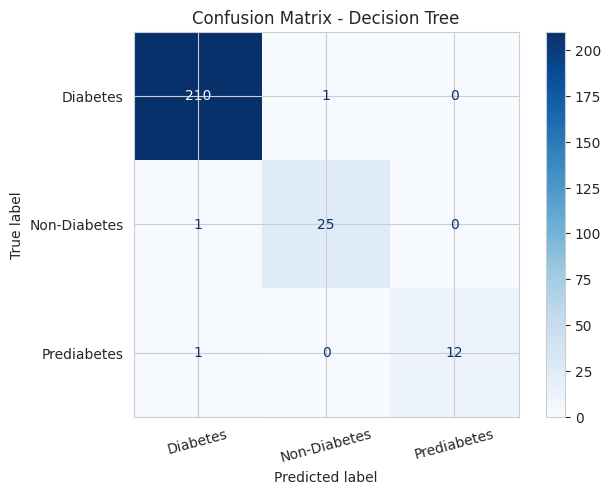

In [76]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
evaluasi_model("Decision Tree", y_test, y_pred_dt)

Hasil **Decision Tree** menunjukkan performa model yang sangat baik dengan **akurasi 98,80%**. Dari 250 data uji, **210 data Diabetes, 25 Non-Diabetes, dan 12 Prediabetes** berhasil diklasifikasikan dengan benar. Kesalahan prediksi hanya terjadi pada beberapa data, yaitu **3 data yang salah klasifikasi**. Nilai **precision, recall, dan F1-score** juga tinggi, sehingga model mampu membedakan ketiga kelas dengan baik.

**Kesimpulan:** Decision Tree memiliki performa klasifikasi yang sangat baik pada dataset ini, dengan kesalahan prediksi yang sangat sedikit.


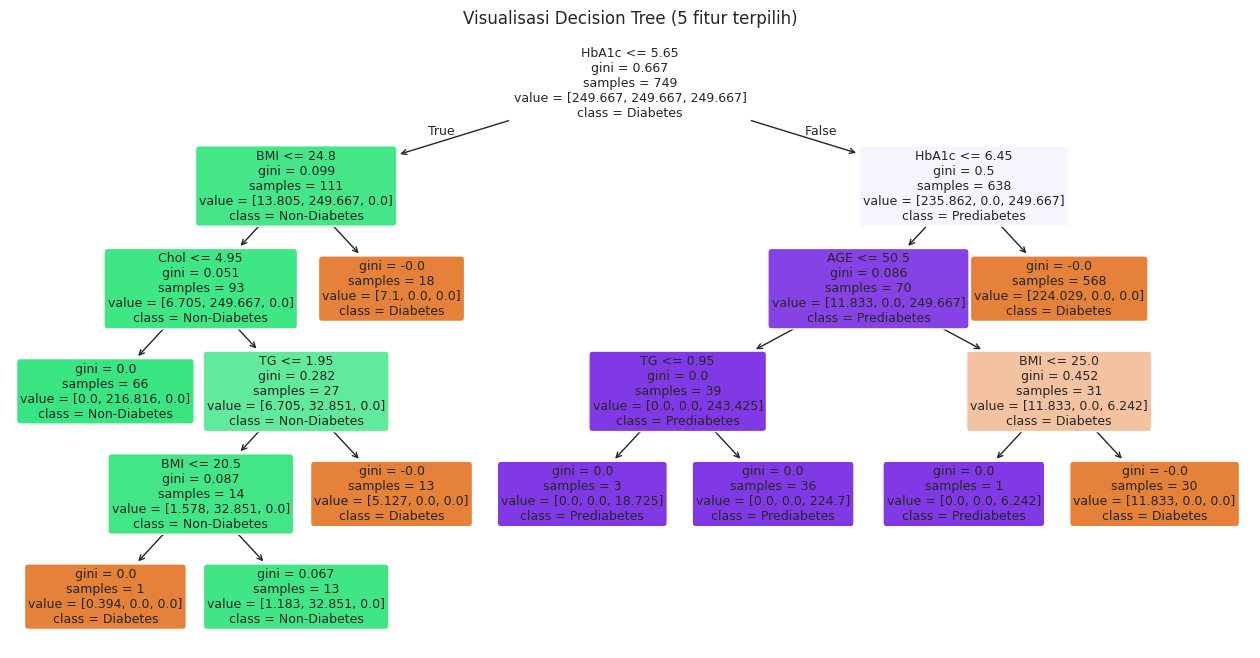

In [77]:
plt.figure(figsize=(16, 8))
plot_tree(dt_model, feature_names=fitur, class_names=le.classes_, filled=True, rounded=True, fontsize=9)
plt.title("Visualisasi Decision Tree (5 fitur terpilih)")
plt.show()

Visualisasi tersebut menunjukkan **cara Decision Tree mengambil keputusan dalam mengklasifikasikan data** berdasarkan 5 fitur terpilih, yaitu **BMI, HbA1c, AGE, Chol, dan TG**.

* **Node paling atas** merupakan titik awal pengambilan keputusan.
* Model pertama kali menggunakan **BMI ≤ 24,8** untuk membagi data.
* Selanjutnya, model menggunakan **HbA1c, AGE, Chol, dan BMI** pada cabang-cabang berikutnya.
* **`gini`** menunjukkan tingkat ketidakmurnian data; semakin mendekati **0**, semakin jelas data dalam node tersebut termasuk satu kelas.
* **`samples`** menunjukkan jumlah data pada node.
* **`class`** menunjukkan kelas yang diprediksi oleh node tersebut.

**Intinya:** diagram ini memperlihatkan bagaimana Decision Tree menggunakan kondisi dari fitur secara bertahap hingga menentukan apakah suatu data termasuk **Diabetes, Non-Diabetes, atau Prediabetes**.


##Model 2: Random Forest

===== Random Forest =====
Akurasi: 98.40%

              precision    recall  f1-score   support

    Diabetes       0.99      1.00      0.99       211
Non-Diabetes       0.96      1.00      0.98        26
 Prediabetes       1.00      0.77      0.87        13

    accuracy                           0.98       250
   macro avg       0.98      0.92      0.95       250
weighted avg       0.98      0.98      0.98       250



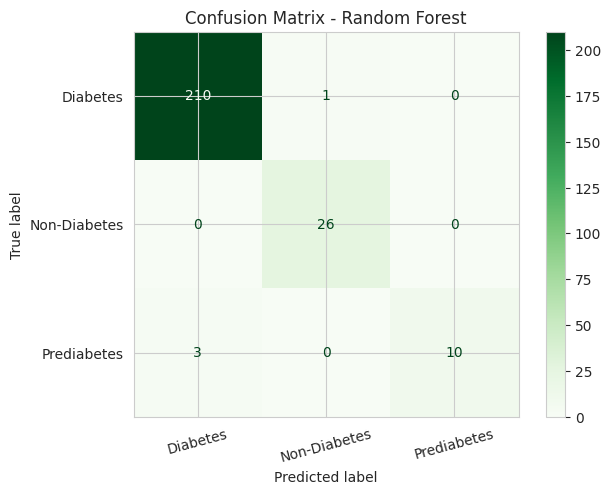

In [78]:
rf_model = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
evaluasi_model("Random Forest", y_test, y_pred_rf)

Hasil **Random Forest** menunjukkan akurasi sebesar **98,40%** pada 250 data testing. Model berhasil mengklasifikasikan **210 Diabetes, 26 Non-Diabetes, dan 10 Prediabetes** dengan benar. Terdapat beberapa kesalahan, terutama pada kelas **Prediabetes**, yaitu 3 data diprediksi sebagai Diabetes. Nilai **precision dan recall** secara keseluruhan juga tinggi, sehingga Random Forest memiliki performa klasifikasi yang sangat baik, meskipun sedikit lebih rendah dibandingkan **Decision Tree (98,80%)**.


##Model 3: SVM

===== SVM (kernel=rbf) =====
Akurasi: 94.00%

              precision    recall  f1-score   support

    Diabetes       0.99      0.94      0.97       211
Non-Diabetes       0.83      0.92      0.87        26
 Prediabetes       0.57      0.92      0.71        13

    accuracy                           0.94       250
   macro avg       0.80      0.93      0.85       250
weighted avg       0.96      0.94      0.94       250



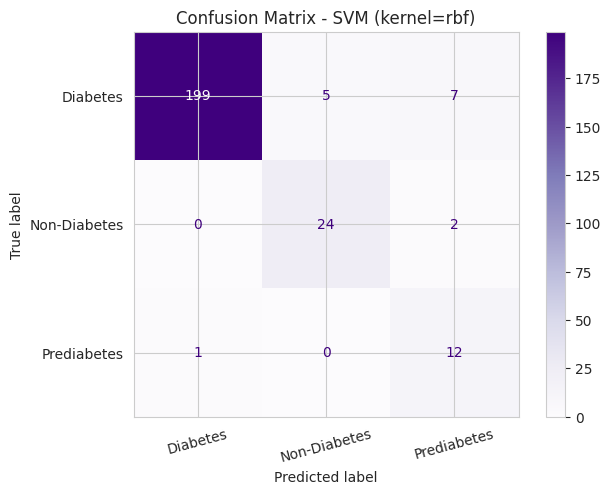

In [79]:
svm_model = SVC(kernel="rbf", C=1.0, class_weight="balanced", random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)
evaluasi_model("SVM (kernel=rbf)", y_test, y_pred_svm)

Hasil **SVM dengan kernel RBF** menunjukkan akurasi **94%** pada 250 data testing. Model menggunakan **RBF (Radial Basis Function)** untuk menangani pola data yang tidak linear, sehingga dapat membuat batas pemisah yang lebih fleksibel antara kelas **Diabetes, Non-Diabetes, dan Prediabetes**. Model berhasil mengklasifikasikan **199 Diabetes, 22 Non-Diabetes, dan 12 Prediabetes** dengan benar. Dibandingkan Decision Tree (**98,80%**) dan Random Forest (**98,40%**), SVM memiliki akurasi paling rendah pada dataset ini.


## Perbandingan Model

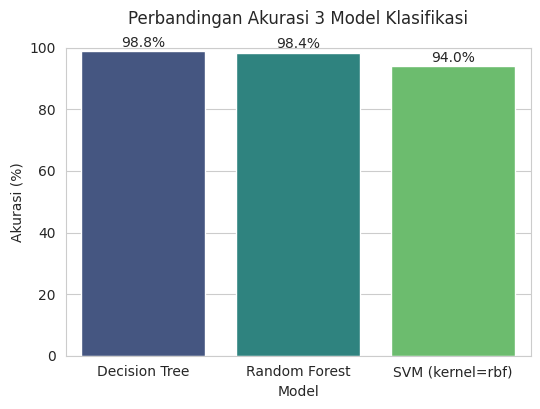

,Model,Akurasi,Akurasi (%)
0,Decision Tree,0.988,98.8
1,Random Forest,0.984,98.4
2,SVM (kernel=rbf),0.940,94.0


In [81]:
hasil_df = pd.DataFrame(list(hasil_model.items()), columns=["Model", "Akurasi"])
hasil_df["Akurasi (%)"] = (hasil_df["Akurasi"] * 100).round(2)
hasil_df = hasil_df.sort_values("Akurasi", ascending=False).reset_index(drop=True)

plt.figure(figsize=(6, 4))
sns.barplot(data=hasil_df, x="Model", y="Akurasi (%)", hue="Model", palette="viridis", legend=False)
plt.ylim(0, 100)
for i, v in enumerate(hasil_df["Akurasi (%)"]):
    plt.text(i, v + 1.5, f"{v}%", ha="center")
plt.title("Perbandingan Akurasi 3 Model Klasifikasi", y=1.05)
plt.show()

hasil_df

Barplot menunjukkan perbandingan akurasi dari **tiga model klasifikasi** menggunakan 5 fitur terpilih pada dataset 1000 baris. **Decision Tree** memiliki akurasi tertinggi sebesar **98,8%**, diikuti **Random Forest 98,4%**, sedangkan **SVM dengan kernel RBF** memperoleh **94%**. Jadi, berdasarkan hasil pengujian, **Decision Tree menjadi model dengan performa terbaik** dalam melakukan klasifikasi diabetes pada dataset ini.


## Kesimpulan Akhir Notebook

Notebook ini berhasil membangun dan mengevaluasi model klasifikasi untuk memprediksi status diabetes pasien (`Non-Diabetes`, `Prediabetes`, `Diabetes`). Berikut adalah poin-poin penting dari analisis:

1.  **Data Loading & Preprocessing**: Dataset awal terdiri dari 1000 baris dengan 11 fitur. Data dibersihkan dari nilai yang hilang dan `CLASS` serta `Gender` diformat ulang. Teridentifikasi adanya *imbalance* kelas, yang ditangani dengan menggunakan `class_weight="balanced"` pada model.

2.  **Feature Selection**: Dengan menggunakan Random Forest untuk menghitung `feature_importance_`, lima fitur paling berpengaruh diidentifikasi: `HbA1c`, `BMI`, `AGE`, `Chol`, dan `TG`. Pemilihan ini didasarkan pada kontribusi signifikan fitur-fitur tersebut terhadap klasifikasi, memungkinkan model yang lebih ringkas tanpa mengorbankan performa secara drastis.

3.  **Model Training & Evaluation**: Tiga algoritma klasifikasi dilatih dan dievaluasi menggunakan 5 fitur terpilih:
    *   **Decision Tree**: Mencapai akurasi tertinggi sebesar **98.8%**.
    *   **Random Forest**: Mencapai akurasi **98.4%**.
    *   **SVM (kernel=rbf)**: Mencapai akurasi **94%**.

    Visualisasi *confusion matrix* dan *classification report* digunakan untuk memahami performa setiap model secara mendalam.

4.  **Perbandingan Model**: Berdasarkan metrik akurasi, **Decision Tree** terbukti menjadi model terbaik untuk dataset ini. Meskipun Random Forest memiliki akurasi yang sangat dekat, Decision Tree menunjukkan sedikit keunggulan dalam klasifikasi diabetes pada data ini.

Secara keseluruhan, proyek ini menunjukkan bagaimana pemilihan fitur yang cermat dan perbandingan model yang sistematis dapat menghasilkan model klasifikasi yang sangat akurat untuk diagnosis diabetes.